# Домашнее задание 5

In [31]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category=warn)

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import List, Tuple, Optional
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
device = torch.device("mps")
print(f"Device: {device}")

PyTorch: 2.10.0
Torchvision: 0.25.0
Device: mps


## Трансформер с Multi-Head Attention

In [32]:
def positional_encoding(seq_len, d_model):
    PE = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    
    PE[:, 0::2] = torch.sin(position * div_term)
    PE[:, 1::2] = torch.cos(position * div_term)

    return PE


class TransformerModelWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=8, num_layers=6, hidden_dim=256, dropout=0.1, max_seq_len=128):
        super(TransformerModelWithAttention, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        self.register_buffer('positional_encoding_buffer', positional_encoding(max_seq_len, hidden_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Выходной классификатор
        self.fc_out = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # Линейное эмбеддинг входных патчей
        x = self.embedding(x)
        
        # Добавление позиционных кодировок
        x = x + self.positional_encoding_buffer[:seq_len, :].unsqueeze(0) 
        
        # Пропускание через трансформер-энкодер
        encoder_output = self.transformer_encoder(x)
        
        x = encoder_output.mean(dim=1)
        
        # Классификация
        logits = self.fc_out(x)
        return logits

## Датасет: Intel Image Classification

In [ ]:
# Параметры датасета
img_size = 64
patch_size = 8
n_patches = (img_size // patch_size) ** 2 # 64 патча на изображение
patch_dim = patch_size * patch_size * 3 # 192 = 8*8*3 (размер каждого патча)
seq_len = n_patches # Длина последовательности
n_classes = 6
batch_size = 64

data_root = "/Users/ivanpetrusa/Desktop/DL/HSE_Fundamentals_of_DL_2026/HW/data/intel_images"

print(f"Патчей на изображение: {n_patches}")
print(f"Размерность патча: {patch_dim}")
print(f"Длина последовательности: {seq_len}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = ImageFolder(os.path.join(data_root, "train"), transform=train_tf)
test_ds = ImageFolder(os.path.join(data_root, "test"), transform=test_tf)

class_names_list = train_ds.classes
print(f"Классы: {class_names_list}")
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

def img_to_patches(imgs: torch.Tensor) -> torch.Tensor:
    B, C, H, W = imgs.shape
    p = patch_size
    x = imgs.reshape(B, C, H // p, p, W // p, p)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // p) * (W // p), p * p * C)
    return x

Патчей на изображение: 64
Размерность патча: 192
Длина последовательности: 64
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 14034, Test: 3000


## Визуализация примеров и патчей

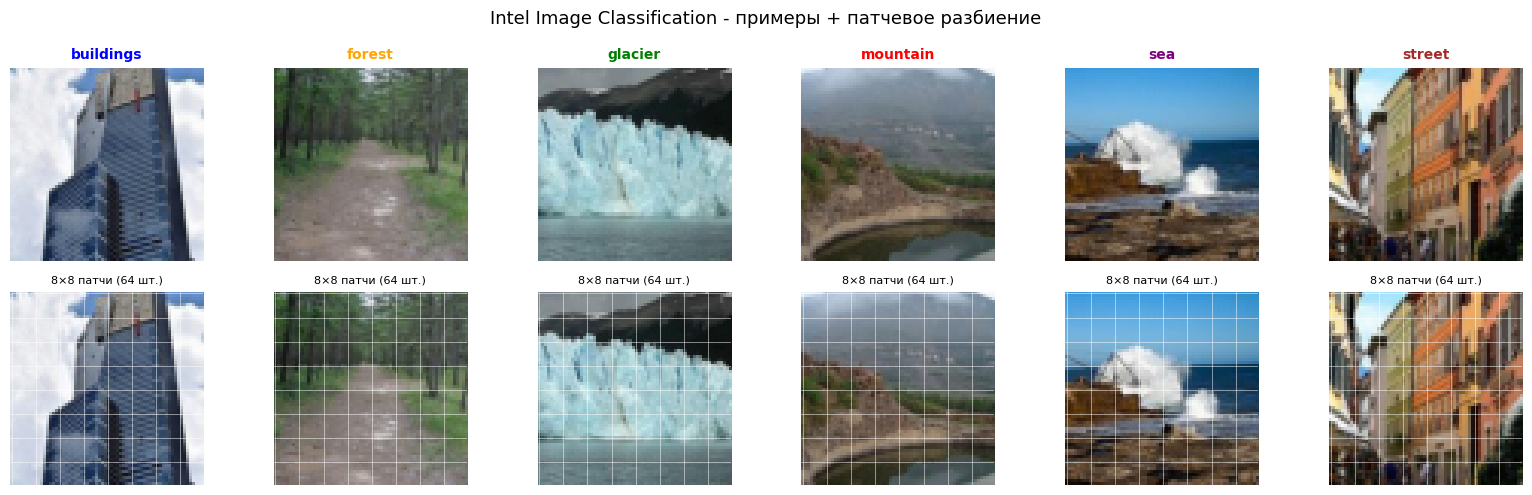

In [34]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
for cls_idx, cls_name in enumerate(class_names_list):
    sample_idx = next(i for i, (_, l) in enumerate(test_ds) if l == cls_idx)
    img_t, _ = test_ds[sample_idx]
    img_show = inv_norm(img_t).permute(1, 2, 0).clip(0, 1).numpy()

    axes[0, cls_idx].imshow(img_show)
    axes[0, cls_idx].set_title(cls_name, fontsize=10, color=colors[cls_idx], fontweight="bold")
    axes[0, cls_idx].axis("off")
    axes[1, cls_idx].imshow(img_show)
    for px in range(0, img_size, patch_size):
        axes[1, cls_idx].axhline(px, color="white", lw=0.5, alpha=0.7)
        axes[1, cls_idx].axvline(px, color="white", lw=0.5, alpha=0.7)
    axes[1, cls_idx].axis("off")
    axes[1, cls_idx].set_title(f"8×8 патчи ({n_patches} шт.)", fontsize=8)

axes[0, 0].set_ylabel("Оригинал", fontsize=10)
axes[1, 0].set_ylabel("Патчи", fontsize=10)
plt.suptitle("Intel Image Classification - примеры + патчевое разбиение", fontsize=13)
plt.tight_layout()
plt.show()

## Трансформер для классификации изображений

In [ ]:
# Гиперпараметры модели
hidden_dim = 128
num_heads = 8
num_layers = 4
dropout = 0.1

class VisionTransformerClassifier(nn.Module):
    def __init__(self, patch_dim, num_classes, hidden_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        
        # Патчевый эмбеддинг + нормализация
        self.patch_embed = nn.Sequential(
            nn.Linear(patch_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        
        # Трансформер-энкодер
        self.transformer = TransformerModelWithAttention(
            input_dim=hidden_dim,
            num_classes=num_classes,
            num_heads=num_heads,
            num_layers=num_layers,
            hidden_dim=hidden_dim,
            dropout=dropout,
            max_seq_len=seq_len + 1
        )

    def forward(self, imgs):
        x = img_to_patches(imgs) 
        x = self.patch_embed(x)
        logits = self.transformer(x)
        return logits


model = VisionTransformerClassifier(
    patch_dim=patch_dim,
    num_classes=n_classes,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {total_params:,}")
print(model)

Параметров: 835,334
VisionTransformerClassifier(
  (patch_embed): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (transformer): TransformerModelWithAttention(
    (embedding): Linear(in_features=128, out_features=128, bias=True)
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
  

## Обучение модели

Epoch 1/30:   0%|          | 0/220 [00:00<?, ?it/s]

[  1/30] train loss=1.1227 acc=0.548 | test loss=0.8994 acc=0.651


Epoch 2/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/220 [00:00<?, ?it/s]

...

Epoch 27/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/220 [00:00<?, ?it/s]

[ 30/30] train loss=0.2594 acc=0.907 | test loss=0.6390 acc=0.798
Лучшая точность на test: 0.819


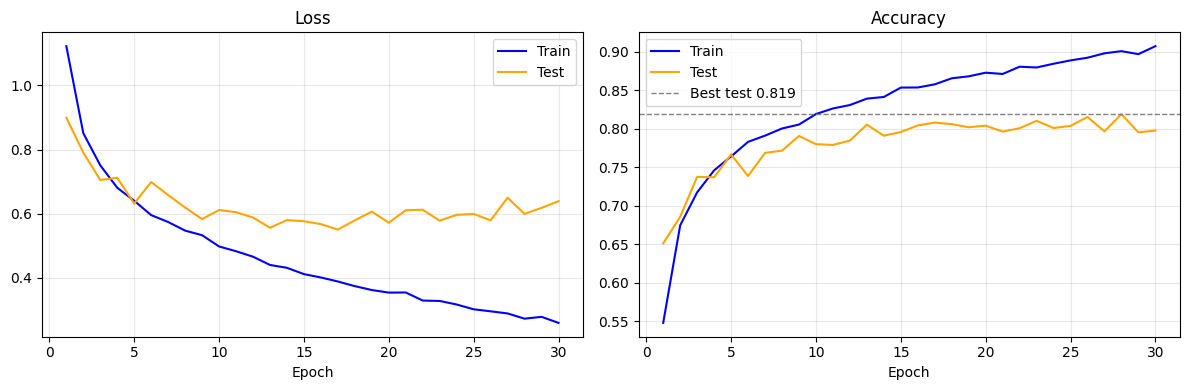

In [36]:
# Параметры обучения
epochs = 30
learning_rate = 3e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

best_test_acc = 0.0
for epoch in range(1, epochs + 1):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        total += len(labels)

    train_loss /= total
    train_acc = correct / total
    test_loss, test_acc = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_transformer_intel_hw5.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}/{epochs}] "
              f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"test loss={test_loss:.4f} acc={test_acc:.3f}")

print(f"Лучшая точность на test: {best_test_acc:.3f}")

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train", color="blue")
axes[0].plot(ep, history["test_loss"], label="Test", color="orange")
axes[0].set_title("Loss", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(ep, history["train_acc"], label="Train", color="blue")
axes[1].plot(ep, history["test_acc"], label="Test", color="orange")
axes[1].axhline(best_test_acc, color="gray", ls="--", lw=1, label=f"Best test {best_test_acc:.3f}")
axes[1].set_title("Accuracy", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Визуализация весов внимания

In [37]:
# Загрузка лучшей модели
model.load_state_dict(torch.load("best_transformer_intel_hw5.pth", map_location=device))
model.eval()

# Функция для извлечения весов внимания из трансформера
def get_attention_weights(model, imgs):
    x = img_to_patches(imgs)  
    x = model.patch_embed(x)
    
    seq_len = x.shape[1]
    x = x + model.transformer.positional_encoding_buffer[:seq_len, :].unsqueeze(0)

    attention_weights = []
    
    # Проход через слои трансформера
    for layer in model.transformer.transformer_encoder.layers:
        # Получение самовнимания
        attn_output, attn_weights = layer.self_attn(x, x, x, average_attn_weights=False)
        attention_weights.append(attn_weights) 
        x = layer.self_attn(x, x, x)[0]
        x = layer.linear1(layer.activation(x))
        x = layer.dropout1(x)
        x = layer.linear2(x)
        x = layer.dropout2(x)
        x = x + attn_output  # добавляем выход внимания обратно

    return attention_weights

# Получение примеров из каждого класса
ex_imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if any(l == c for c in range(n_classes))]).to(device)[:6]
with torch.no_grad():
    attention_weights = get_attention_weights(model, ex_imgs)

print(f"Получены веса внимания для {len(attention_weights)} слоев")
print(f"Форма каждого слоя: {attention_weights[0].shape}")

Получены веса внимания для 4 слоев
Форма каждого слоя: torch.Size([6, 8, 64, 64])


## Визуализация тепловых карт внимания

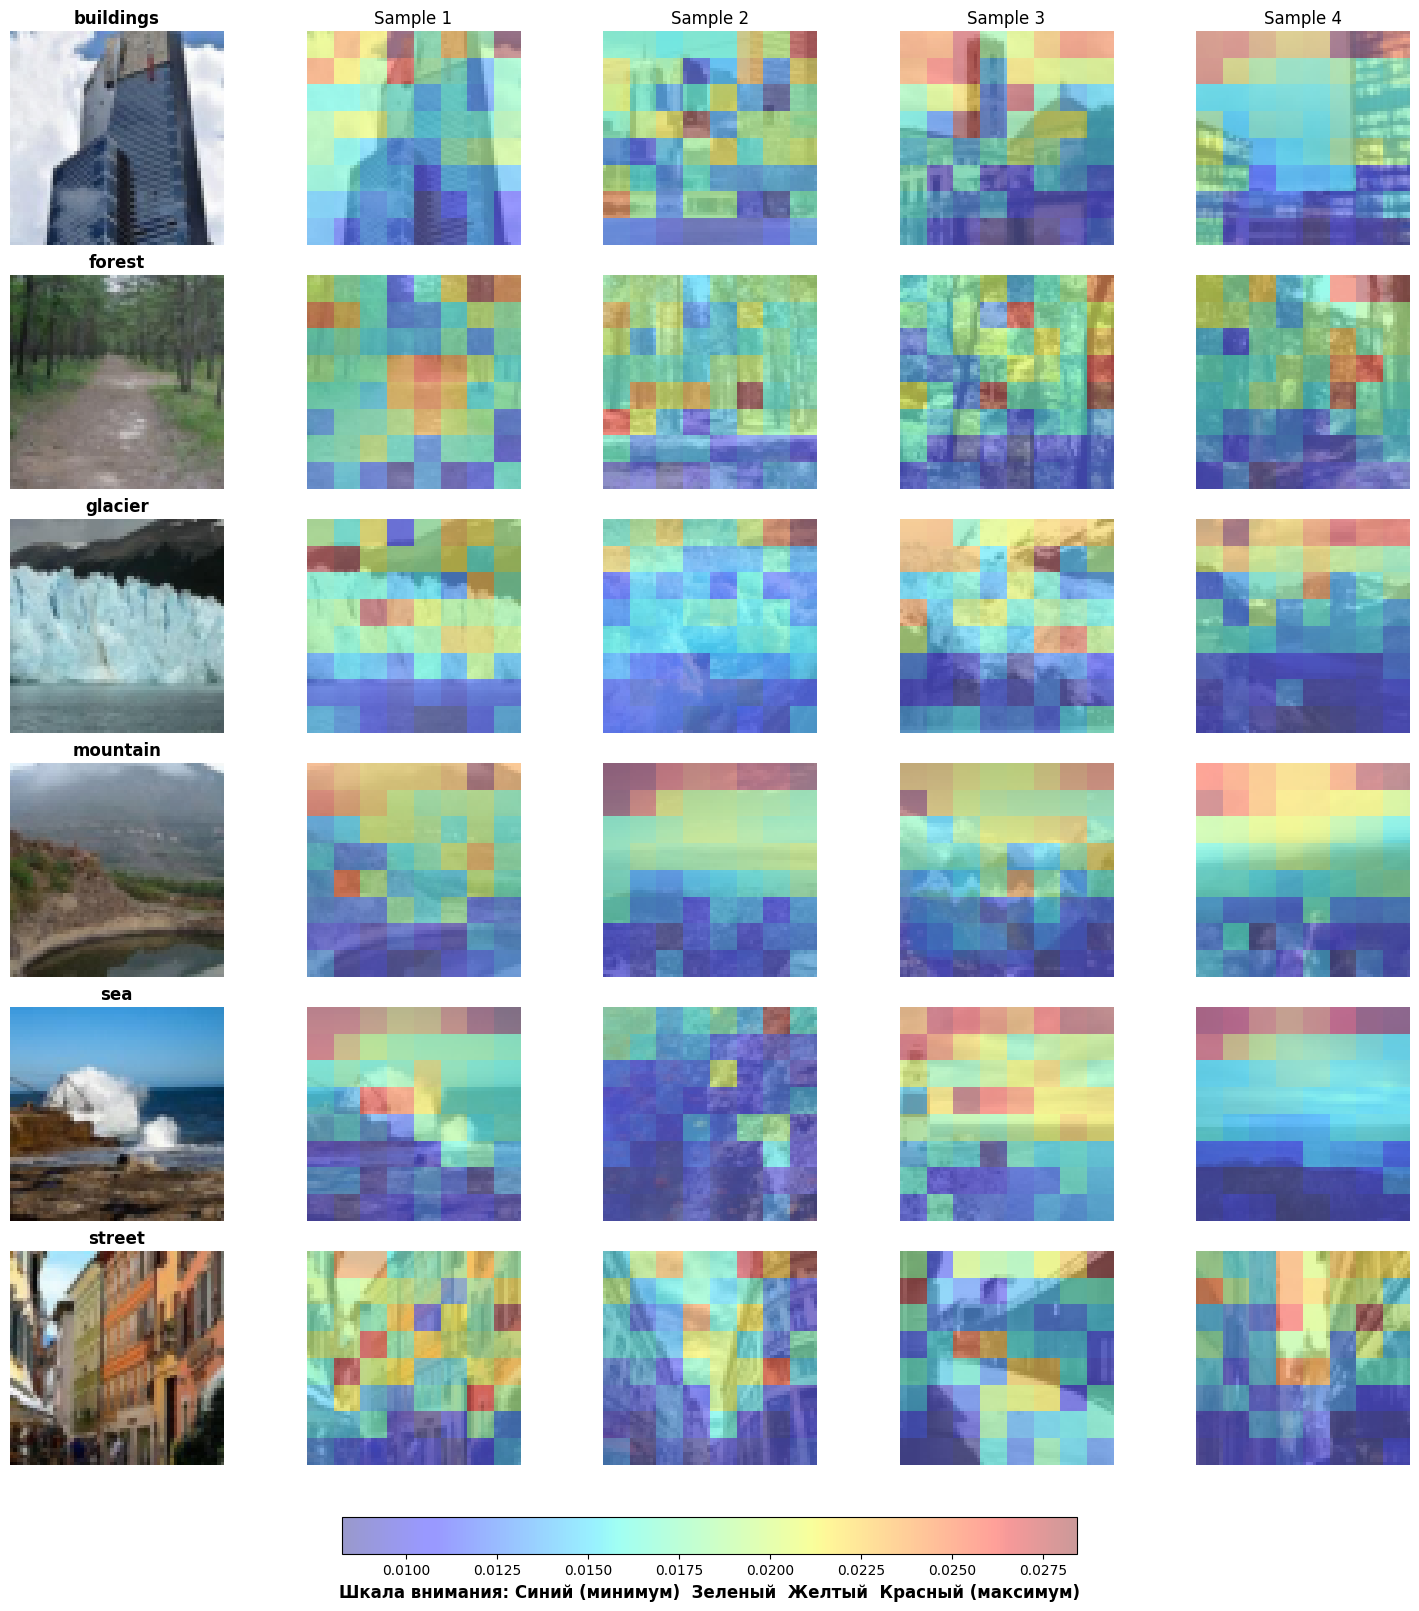

In [ ]:
model.load_state_dict(torch.load("best_transformer_intel_hw5.pth", map_location=device))
model.eval()

# Функция для получения карт внимания для заданного класса
def get_attention_maps(cls_label, n=4):
    # Выборка изображений нужного класса из тестовой выборки
    imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if l == cls_label][:n]).to(device)
    
    attention_weights = []
    
    # Модификация forward метода для возврата и attention_weights
    with torch.no_grad():
        x = model.patch_embed(img_to_patches(imgs))
        x = x + model.transformer.positional_encoding_buffer[:seq_len, :].unsqueeze(0)
        
        # Ручная прогонка через слои энкодера
        for layer in model.transformer.transformer_encoder.layers:
            x_norm = layer.norm1(x)
            attn_output, attn_weight = layer.self_attn(x_norm, x_norm, x_norm, need_weights=True)
            x = x + layer.dropout1(attn_output)
            x = x + layer.dropout2(layer.linear2(layer.dropout(layer.activation(layer.linear1(layer.norm2(x))))))
            
            # веса внимания (только последнего слоя)
            attention_weights.append(attn_weight.cpu())

    return attn_weight.cpu().numpy()

# Получение внимания для всех классов
attn_weights_cls = []
for cls in range(n_classes):
    attn = get_attention_maps(cls)
    attn_weights_cls.append(attn)

# Визуализация 
fig, axes = plt.subplots(n_classes, 5, figsize=(15, 3 * n_classes))
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
im = None 

for cls in range(n_classes):
    attn = attn_weights_cls[cls]
    imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if l == cls][:4]).cpu()
    
    # Класс и первое изображение (оригинал)
    axes[cls, 0].imshow(inv_norm(imgs[0]).permute(1, 2, 0).clip(0, 1).numpy())
    axes[cls, 0].set_title(class_names_list[cls], fontsize=12, fontweight="bold")
    axes[cls, 0].axis('off')
    
    for i in range(4):
        # Усреднение карты внимания по всем patch_to_patch связям, чтобы получить важность каждого патча (8x8)
        attn_map = attn[i].mean(axis=0).reshape(8, 8)
        
        ax = axes[cls, i+1]
        img_np = inv_norm(imgs[i]).permute(1, 2, 0).clip(0, 1).numpy()
        ax.imshow(img_np, alpha=0.6)
        
        map_resized = np.kron(attn_map, np.ones((img_size // 8, img_size // 8)))
        im = ax.imshow(map_resized, cmap='jet', alpha=0.4)
        ax.axis('off')
        if cls == 0:
            ax.set_title(f'Sample {i+1}')

plt.tight_layout()

# Общая шкала цветов 
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.5, pad=0.03)
cbar.set_label('Шкала внимания: Синий (минимум)  Зеленый  Желтый  Красный (максимум)', fontsize=12, fontweight='bold')

plt.show()

## Анализ внимания для разных классов

### 1. Обучение и сравнение с xLSTM
* **Точность:** Трансформер показал 81.9% точности на тестовых данных.
* **Сравнение с прошлой домашкой:** Модель Vision-xLSTM показывала около 80.6%. То есть Трансформер справился немного лучше.
* **Переобучение:** Как и с xLSTM, после 10-15 эпох ошибка на тесте (test loss) перестает падать, а на трейне продолжает стремиться к нулю. Это говорит о начавшемся переобучении.

### 2. Анализ Attention Maps
Поскольку сумма всего внимания на картинке строго равна 100% (из-за функции Softmax), модель отдает почти всё внимание (красные и желтые зоны) 2-4 самым важным квадратикам, оставляя остальным районам крохи (синие зоны).

Вот что можно заметить:
1. **Игнорирование скучного фона (Синий цвет):** Гладкое небо, пустой асфальт или ровная вода не дают модели полезной информации. Она их игнорирует
2. **Поиск границ и горизонтов (Красный цвет):** На пейзажах (море, горы, ледники) максимальное внимание почти всегда ложится ровно на линию горизонта или стык объектов (например, где вода бьется о берег или горы касаются неба).
3. **Текстуры и геометрия:** В классе forest нет одного главного объекта, поэтому внимание распределяется по всем деревьям и листьям. А вот в  buildings, street модель четко цепляется за вертикальные линии фасадов.
4. **Сравнение:** В отличие от LSTM, который считывает изображение шаг за шагом, трансформер видит все 64 патча одновременно и мгновенно находит самые важные куски изображения, в какой бы части картинки они ни находились.